<a href="https://colab.research.google.com/github/MatchLab-Imperial/deep-learning-course/blob/master/02_CNN_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Convolutional Neural Networks

This tutorial addresses the basic concepts regarding Convolutional Neural Networks and their implementation using the PyTorch framework.
Convolutional Neural Networks (CNNs) are a class of feed-forward artificial neural architecture. They are applied to analyse visual 2D imagery, meaning that we can feed images directly into a CNN without the need to flatten them into a 1D vector as done in the previous tutorial.
CNNs have revolutionised the field of computer vision in the last decade. In 2012 Alex Krizhevsky introduced the AlexNet architecture to win the ImageNet Challenge (one of the most important competitions on image classification within the Computer Vision community), by reducing the top-5 error more than 10 percentage points, which was an incredible improvement at that time. As of now, CNNs are used not only on image classification but in many other computer vision tasks.

![](https://cdn-5f733ed3c1ac190fbc56ef88.closte.com/wp-content/uploads/2017/03/alexnet_small-1.png)

The image above is from [cv-tricks' blog](https://cv-tricks.com/cnn/understand-resnet-alexnet-vgg-inception/) and shows the proposed AlexNet architecture. It is composed of 5 convolutional layers followed by 3 fully connected layers. Nowadays, we can find much deeper and more complex architectures, which outperform AlexNet on the ImageNet Challenge.







In [7]:
# Enter your CID below before running the submission cells.
CID = "00000000"

In [8]:
from pathlib import Path

SUBMISSION_DIR = Path("./submission")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

def submission_path(suffix):
    student_cid = CID.strip()
    if not student_cid or student_cid == "YOUR_CID":
        raise ValueError("Enter your CID in the CID cell before saving submission files.")
    return SUBMISSION_DIR / f"{student_cid}_{suffix}"

print(f"Submission files will be saved in: {SUBMISSION_DIR.resolve()}")

Submission files will be saved in: /Volumes/WDSN5000/Users/d1meac/Documents/DeepLearningNotebooks/submission


In [9]:
!pip install torchinfo
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional
from torch import optim
from torch.utils import data
import torchinfo
from torchvision import datasets, transforms


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [10]:
# Utility function to control randomness for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

## CNN Structure

The basic pipeline of common CNNs consists of an image as input and a stack of convolutional layers that extract a feature representation from the input image. The final shape of the image representation is conditioned on the type of problem/task that the architecture is facing. For instance, the output of the last layer in a classification problem is a probability vector. Each dimension of the probability vector represents how likely is that the input image belongs to a specific class. However, the architecture design is up to us, and therefore, we could code a network that outputs a single value for regression problems, or that generates a new image map for semantic segmentation. Now, let's dig in a bit into CNN and introduce some layers that are widely used.

### 2D Convolutional Layer

The most common layer in any CNN architecture is the 2D convolutional layer. Convolutional layers are specifically designed to extract features from images or even extract features from previously extracted features. As shown in the following illustration, 2D convolutions apply the same filter to the full image. And therefore, due to its nature, 2D convolutional filters exploit the local information presented in images, making them a powerful tool for image analysis.

![](https://cdn-images-1.medium.com/max/800/1*Fw-ehcNBR9byHtho-Rxbtw.gif)

Image [source](https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1).

The latest deep learning frameworks have made possible the integration of convolutional layers easily on our architectures with only a single line of code. We will address here how 2D convolutions work since full understanding is needed to comprehend how any CNN operates. The following images and some explanations can be further explored on the original [Irhum Shafkat's blog](https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1) or in the [Neural Networks and Deep Learning](http://neuralnetworksanddeeplearning.com/) book. Both are strongly recommended.

To understand 2D convolutions, we need to define first what a kernel is. Kernels are simply matrices of numbers. The numbers on the kernels are the so-called weights, and the weights on the kernels change as we train the network. Hence, network training aims to optimise the network's parameters (update the kernel weights) such that the cost function is minimised.

The 2D convolution operation takes the network's kernels and "slides" them over the input image (alike to a sliding window) as in the following image from [PyImageSearch](https://www.pyimagesearch.com/2015/03/23/sliding-windows-for-object-detection-with-python-and-opencv/) blog:

![](https://pyimagesearch.com/wp-content/uploads/2014/10/sliding_window_example.gif)

In each step, the network performs an element-wise multiplication with the elements that are currently on. The results of this elementwise multiplication are added to obtain the output value of the operation. CNNs repeat previous step for all the positions of the sliding window, composing at the end the feature map. This generated feature map can go through another 2D convolutional layer and create more powerful features.

>

![](https://cdn-images-1.medium.com/max/800/1*Zx-ZMLKab7VOCQTxdZ1OAw.gif)

>
The previous image shows the 2D convolution operation. Thus, the new feature values are the weighted sum of all the elements in the sliding window after the elementwise multiplication between input and kernel.  The bigger the size of the kernel is, the more feature elements contribute to the final output value. In contrast to fully connected layers, where a new feature value is a weighted sum over **all** input values, as mentioned, 2D convolutions compute features based on local areas. In other words, instead of looking at every input component, they consider only features coming from close locations.

In the above example, the input image on the left has a size of 5x5 and the dimension of the resulting feature map is 3x3, showing that the size of the output maps is not always equal to the input. Hence, the output size can be computed by doing:

$O = W - K + 1$,

where $O$ is the output height/length, $W$ is the input height/length and $K$ is the kernel size. The output size is not only conditioned on the input size but also on the kernel size. Check in the following code cell how the output feature map shape changes as you increase the kernel size. In Pytorch, we define the layer by using `Conv2D` from `torch.nn` (documentation [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)).









In [11]:
# Define a simple model with a single 2D convolutional layer
class SimpleConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3)

    def forward(self, x):
        return self.conv(x)

# Instantiate and run the model
input = torch.randn((1, 1, 100, 100))  # (batch_size, num_channels, height, width)
model = SimpleConvNet()
output = model(input)

# Compare input and output size
print('Input size: ({:}, {:}, {:})'.format(input.shape[1], input.shape[2], input.shape[3]))
print('Output size: ({:}, {:}, {:})'.format(output.shape[1], output.shape[2], output.shape[3]))

Input size: (1, 100, 100)
Output size: (1, 98, 98)


Moreover, the kernel size and the input size are not the only parameters affecting the output size. We are going to introduce two extra elements that change the size of the output map: the padding and the stride.

### Adding Padding to Input Features

In some tasks, such as [image translation](https://arxiv.org/pdf/1611.07004.pdf), we need the output size to be equal to the input size. The solution to that is using padding, where extra edges are added to the input features so that the dimension is not reduced after the convolutional layer. Normally those pixels have $0$ value (termed zero-padding), but depending on the application other methods could be used, e.g., reflection or symmetric padding.

![](https://cdn-images-1.medium.com/max/800/1*1okwhewf5KCtIPaFib4XaA.gif)

If padding is used, the new output size can be computed by doing:

$O = W - K + 2P+ 1$,

where $P$ is the padding value. $P$ must be set in concordance with the kernel size if dimensionality wants to be preserved. Padding can be added to the `Conv2d` layer by using the padding argument.

In [12]:
# Define model with 'same' padding
class SamePadConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding='same')

    def forward(self, x):
        return self.conv(x)

# Instantiate and run the model
input = torch.randn((1, 1, 100, 100))  # (batch_size, num_channels, height, width)
model = SamePadConvNet()
output = model(input)

# Compare input and output size
print('Input size: ({:}, {:}, {:})'.format(input.shape[1], input.shape[2], input.shape[3]))
print('Output size: ({:}, {:}, {:})'.format(output.shape[1], output.shape[2], output.shape[3]))

Input size: (1, 100, 100)
Output size: (1, 100, 100)


### Using Stride in Convolutional Layers

The stride operation allows the convolutional layers to skip some of the sliding windows explained above. Hence, instead of jumping one pixel apart, we can define the number of skipped elements before computing the weighting sum between the kernel's weights and input features. A stride of 1 means that features will be extracted from all windows a pixel apart, so basically, every single window is computed. A stride of 2 means that we are selecting windows 2 pixels apart, skipping every other window in the process. Strides reduce the number of computations and consequently the size of the output map. In practice, as we go deeper into the CNN, the spatial size of the feature map gets smaller while the number of channels increases. Moreover, we can further reduce the size of the feature map using pooling operations, which we introduce later in this tutorial.

![](https://cdn-images-1.medium.com/max/800/1*BMngs93_rm2_BpJFH2mS0Q.gif)

If strides are used, the new output size can be computed as:

$O = \dfrac{W - K + 2P}{S}+ 1$,

where $S$ is the stride value. The stride is set in the layer by using the `strides` argument.

In [13]:
# Define model with 'same' padding and stride=2
class StridedSamePadConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            stride=2,
            padding=1,  # 'same' padding for 3x3 kernel with stride 2
        )

    def forward(self, x):
        return self.conv(x)

# Instantiate and run the model
input = torch.randn((1, 1, 100, 100))  # (batch_size, num_channels, height, width)
model = StridedSamePadConvNet()
output = model(input)

# Compare input and output size
print('Input size: ({:}, {:}, {:})'.format(input.shape[1], input.shape[2], input.shape[3]))
print('Output size: ({:}, {:}, {:})'.format(output.shape[1], output.shape[2], output.shape[3]))

Input size: (1, 100, 100)
Output size: (1, 50, 50)


## Differences Between Kernel and Filters

The examples above take as input a single-channel image and compute a feature map with also one channel. However, when dealing with RGB images or feature maps, the input is no longer a single-channel map but, instead, they can have multiple channels. In the case of an RGB image, for each 2D convolution, we will need to define 3 kernels to interact with each of the image's channel colours. This group of kernels is called a filter. Thus, a filter is a collection of kernels that produces a single output.

As a regular practice when defining Deep Learning models, we increase the number of filters in each convolutional layer as we go deeper into the model. Due to the element-wise multiplication, the number of kernels on each filter must be the same that the number of channels in the input feature map.

The next figure shows how the convolution is performed when having three input channels. First, one filter uses its three independent kernels to convolve with the RGB channels of the input image:

![](https://cdn-images-1.medium.com/max/1000/1*8dx6nxpUh2JqvYWPadTwMQ.gif)

Next, each of the processed feature maps is added together to obtain a single channel:

![](https://cdn-images-1.medium.com/max/1000/1*CYB2dyR3EhFs1xNLK8ewiA.gif)

Finally, we add the bias term to obtain the feature map. There is a single bias for the full output channel map. This operation is repeated for all the filters inside the convolutional layer.

Now, we show how to use a `Conv2D` layer that takes an input image with 3 channels and generates an output map with 32 channels.


In [14]:
# Define the PyTorch model
class StridedConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=3,        # 3 input channels (RGB)
            out_channels=32,      # 32 filters
            kernel_size=3,
            stride=2,
            padding=1             # 'same' padding for 3x3 kernel with stride 2
        )

    def forward(self, x):
        return self.conv(x)

# Instantiate and run the model
input = torch.randn((1, 3, 100, 100))  # (batch_size, num_channels, height, width)
model = StridedConvNet()
output = model(input)

# Compare input and output size
print('Input size: ({:}, {:}, {:})'.format(input.shape[1], input.shape[2], input.shape[3]))
print('Output size: ({:}, {:}, {:})'.format(output.shape[1], output.shape[2], output.shape[3]))

Input size: (3, 100, 100)
Output size: (32, 50, 50)


## Activation Functions

As seen in previous tutorials, after a `Linear` layer we usually can find an activation function. We introduce here how to use them after `Conv2D` layers. Those activation functions are a set of operators that maps the feature values to a new set of values, the mapping depends on the function at hand. The main reason for using activation functions is that they add non-linearities to the network, giving more expressive power to the network, which will be able to reproduce more complex functions.

*  **Sigmoid Function** sets the output in the range (0, 1). The sigmoid function is widely used in binary classification problems since its output can be taken as a probability value. `nn.Sigmoid(x)`:

>![](https://i.ibb.co/Ph8dsTv/sigmoid.png)

*  **Tanh Function** is a logistic function as sigmoid, but the range of the tanh function is (-1, 1). Contrary to sigmoid function, where the values close to 0 are set around 0.5, in the tanh function they will be still mapped around the 0 value. `nn.Tanh(x)`:

>![](https://i.ibb.co/68g7LpL/tanh.png)

*  **ReLU Function** is the most common activation function you can find in any current CNN as in general works better than the rest. The range of this function is in \[0, inf). It sets all negative values to 0 and hence is computationally easy to implement. As a drawback, during training some neurons *die*, meaning that the output is 0 for all available data points and no gradient is propagated there. `nn.ReLU(x)`:

>![](https://i.ibb.co/Zd9H8Z4/relu.png)

*  **LeakyReLU Function** is a modified version of the ReLU activation above, which attempts to solve the problem of dying neurons that ReLU has. While ReLU does not backpropagate negative values, Leaky ReLU smooths those values without setting them to 0. That allows the gradients to backpropagate through the network even for negative values. `nn.LeakyReLU(negative_slope=0.3)`:

>![](https://i.ibb.co/dmnJ6h1/leakyrelu.png)

*  **Softmax Function** is another widely activation function for multi-class classification problems and usually is employed as the last activation function in the classification model. This function sets all of the output elements to the range (0, 1). However, the softmax function does not take independently the input values to map it into its probability value. Softmax Function takes an un-normalized vector, $s$, and normalizes it into a probability distribution, $p$, following the softmax expression. As the output is a probability, the output elements add up to 1. `nn.Softmax(x, axis=-1)`. Thus, the output value $p_i$ is computed as:

> $p_{i} = \dfrac{e^{s_i}}{\sum_{\substack{j}}^{N} e^{s_j}}$

The following example shows the feature maps before and after of the ReLU activation function. All values that are negative are set to 0 after the activation function.




In [15]:
# Define model
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            stride=1,
            padding='same',
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        conv_out = self.conv(x)
        relu_out = self.relu(conv_out)
        return conv_out, relu_out

# Instantiate model
input = torch.randn((1, 1, 3, 3))
model = ConvNet()
output_conv, output_relu = model(input)

# Print results
print('Output Network without activation function')
print(output_conv[0, 0])  # print only the single channel

print('\nOutput Network after ReLU activation function')
print(output_relu[0, 0])

Output Network without activation function
tensor([[-0.1196, -0.5682, -0.1616],
        [-0.5084, -0.2567, -0.4367],
        [-0.4041, -0.1206, -0.3162]], grad_fn=<SelectBackward0>)

Output Network after ReLU activation function
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<SelectBackward0>)


## Pooling Layer

It is a common practice to insert a pooling layer between convolutional layers in CNNs. In a standard CNN architecture, we set the feature sizes to become smaller progressively to reduce the computation in the networks, and to merge the information from different spatial locations. To reduce the feature map sizes, we can either use bigger stride size in the convolutional layers or we can use pooling layers. Pooling layers perform a spatial sliding window and apply an operation to reduce the spatial size. Those operations vary depending on the architecture, being the max, mean and min pooling the most typical ones. Here, we will explain the max pooling, although all the others work similarly. Max pooling keeps only the max value in a neighbourhood, where the neighbourhood is defined by the size of the kernel. Let's visualise it, the next example shows the result of a Max Pooling layer with a 2x2 kernel and a stride of 2.

![](https://i.ibb.co/Xp454S4/MaxPool.png)

As in convolutional layers, the final size is conditioned to the stride size of the pooling layer. However, contrary to convolutional layers, pooling layers operate independently on each of the input channels, without modifying the depth of the feature maps. To use max pooling in our model we use, `nn.MaxPooling2d` and define the stride and pooling size.

In [16]:
# Define the model
# input: 100x100 image with 3 channels -> (100, 100, 3) tensor.
# this applies 32 convolution filters of size 3x3 each.
# attribute padding='same' applies zero-padding to the input feature map
# attribute strides=1 applies stride of 1
class ConvMaxPoolNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding='same',
        )
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

# Instantiate and run the model
input = torch.randn((1, 3, 100, 100))  # (batch_size, num_channels, height, width)
model = ConvMaxPoolNet()
output = model(input)

# Compare input and output size
print('Input size: ({:}, {:}, {:})'.format(input.shape[1], input.shape[2], input.shape[3]))
print('Output size: ({:}, {:}, {:})'.format(output.shape[1], output.shape[2], output.shape[3]))

Input size: (3, 100, 100)
Output size: (32, 50, 50)


# Example: Classification on MNIST

In this section, we show how to perform image classification when the input data is a 2D image instead of a flat 1D vector.

As discussed above, Convolutional Neural Networks aim to extract and exploit the local relationships on 2D maps, hence, CNNs are much more convenient for images than Multi-layer Perceptron models.

In [17]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=32)

print(f'Image shape: {train_dataset[0][0].shape}')
print(f"Total number of training samples: {len(train_dataset)}")
print(f"Total number of test samples: {len(test_dataset)}")

Image shape: torch.Size([1, 28, 28])
Total number of training samples: 60000
Total number of test samples: 10000


Now we can define a model composed of convolutional layers, activation functions, and maxpool operators:

In [18]:
class CNN(nn.Module):
    def __init__(self, input_channels=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

    def forward(self, x):
        return self.model(x)

As explained in the previous tutorial, in a classification problem, the output of the model is a probability vector. Each dimension of the vector indicates how likely is that the input image belongs to a specific class.

Up to now, the resulting feature map of the model is a map with the shape *Batch x Weight' x Height' x Channel*, and it needs to be mapped into a vector with shape *Batch x Num Classes*. A common technique to process this mapping is to add a Flatten layer that will reshape the feature map to *Batch x (Weight' * Height' * Channel)*. Following the Flatten layer, we add a dense layer which maps this new feature map to the desired output size.

In [19]:
class ClassificationHead(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        return x

Finally, we can train our CNN and check its performance on MNIST.

In [20]:
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = nn.Sequential(
    CNN(input_channels=1),
    ClassificationHead(input_channels=16 * 7 * 7)
)
model = model.to(device)
print(torchinfo.summary(model, input_size=(1, 1, 28, 28)))

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)

# Training loop
for epoch in range(10):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch + 1}/10] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc*100:.2f}%")

# Evaluation
model.eval()
correct = 0
total = 0
loss_total = 0

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_total += loss.item() * inputs.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += inputs.size(0)

avg_loss = loss_total / total
accuracy = correct / total

print()
print(f'Test loss: {avg_loss}, Test accuracy: {accuracy*100:.2f}%')

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─CNN: 1-1                               [1, 16, 7, 7]             --
│    └─Sequential: 2-1                   [1, 16, 7, 7]             --
│    │    └─Conv2d: 3-1                  [1, 16, 28, 28]           160
│    │    └─ReLU: 3-2                    [1, 16, 28, 28]           --
│    │    └─MaxPool2d: 3-3               [1, 16, 14, 14]           --
│    │    └─Conv2d: 3-4                  [1, 16, 14, 14]           2,320
│    │    └─ReLU: 3-5                    [1, 16, 14, 14]           --
│    │    └─MaxPool2d: 3-6               [1, 16, 7, 7]             --
├─ClassificationHead: 1-2                [1, 10]                   --
│    └─Flatten: 2-2                      [1, 784]                  --
│    └─Linear: 2-3                       [1, 10]                   7,850
Total params: 10,330
Trainable params: 10,330
Non-trainable params: 0
Total mu

# Coursework


## Task 1: Classification

At this point, we know what is a CNN, how they work, and the components needed to design them. In this task, you will investigate how different CNN architectures use a limited number of trainable parameters. For the first part of the coursework, we train on CIFAR10, a classical dataset for image classification. Note that in these tutorials, we use the official test set as our validation set so that everybody uses the same split and can compare results. In a proper machine learning setup, the validation and test sets should be separate.

Design and train **two CNN models**:

1. A **small model** with between **50,000 and 100,000 trainable parameters**.
2. A **large model** with between **200,000 and 300,000 trainable parameters**.

The parameter ranges are deliberately flexible. You do not need to match an exact parameter count, but each model must stay within its assigned range. Both models must accept CIFAR-10 images with shape `(batch_size, 3, 32, 32)` and produce ten output logits. Each model must contain at least two convolutional layers and must have a different architecture from the other model.

You may change the architecture only. You may change the number of convolutional layers, number of filters, kernel sizes, strides, padding, pooling layers, activation functions, and the design of the classifier head. You may also choose how to reduce the final feature map before classification. Do not use pretrained weights or external data. Do not change the dataset, batch size, loss function, optimizer, learning rate, number of epochs, or data augmentation. Batch Normalization and Dropout will be studied in a later tutorial and should not be used here.

The notebook provides two baseline models below. Start from these models, modify their architectures, and use the helper functions to verify the parameter count and compare their learning curves. You do not need to submit the model files or code separately; the required submission items are listed in the Problem Definition section below.

Let's first load the dataset and visualise some examples:

In [1]:
#It may take around 1 min to download 
!wget -q -O ./data/cifar10.zip https://imperialcollegelondon.box.com/shared/static/sspknj7832hnqdzx5gs1f328grxqvsr5.zip
!unzip -oq ./data/cifar10.zip -d ./data
!rm -rf ./data/__MACOSX

Image shape: (32, 32, 3)
Total number of training samples: 50000
Total number of validation samples: 10000


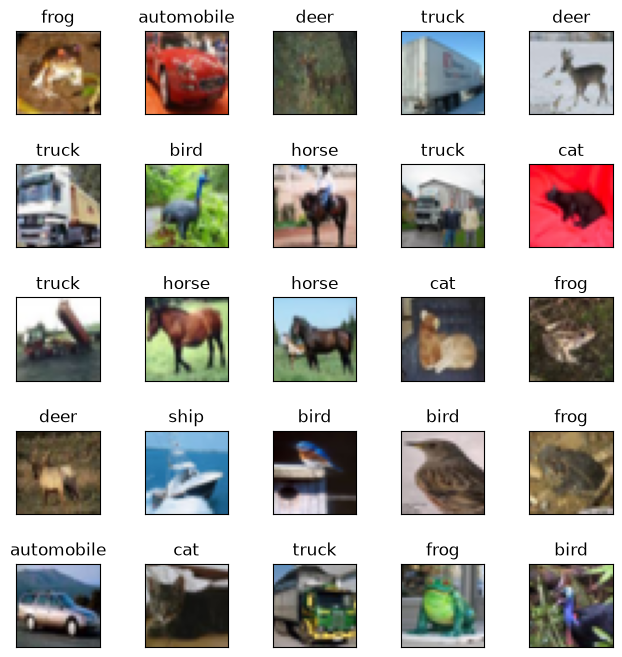

In [21]:
# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Create DataLoaders
train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=32)

# Visualize some examples
X_train = train_dataset.data       # NumPy array of shape (50000, 32, 32, 3)
y_train = np.array(train_dataset.targets)

X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

print('Image shape: {0}'.format(X_train.shape[1:]))
print('Total number of training samples: {0}'.format(X_train.shape[0]))
print('Total number of validation samples: {0}'.format(X_test.shape[0]))

N = 5
start_val = 0  # pick an element for the code to plot the following N**2 values
fig, axes = plt.subplots(N, N, figsize=(8, 8))
class_names = train_dataset.classes  # List of class names: ['airplane', 'automobile', ..., 'truck']

for row in range(N):
    for col in range(N):
        idx = start_val + row + N * col
        axes[row, col].imshow(X_train[idx])
        label_idx = y_train[idx]
        axes[row, col].set_title(class_names[label_idx])
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

fig.subplots_adjust(hspace=0.6)
plt.show()

Now, we are ready to define the Multi-layer Perceptron model and train it.

In [22]:
set_seed(42)

# Define the model
class FullyConnectedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3072, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FullyConnectedNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)
epochs = 20

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        inputs = inputs.view(inputs.size(0), -1) # Flatten the input for MLP
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc*100:.2f}%")

# Evaluation
model.eval()
correct = 0
total = 0
loss_total = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.view(xb.size(0), -1)
        preds = model(xb)
        loss_total += criterion(preds, yb).item() * xb.size(0)
        predicted = torch.argmax(preds, dim=1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)

print()
print(f"Validation loss: {loss_total/total:.4f}, Validation accuracy: {correct/total*100:.2f}%")

Epoch [1/20] - Loss: 1.9909, Accuracy: 25.01%
Epoch [2/20] - Loss: 1.8484, Accuracy: 31.71%


KeyboardInterrupt: 

### Problem Definition

Use the separate setup, helper, architecture, training, and plotting cells below as the main workflow. Modify the architecture of `SmallCNN` and `LargeCNN` while keeping the corresponding parameter count within its required range. The training code, optimizer, and evaluation procedure are provided and must not be changed so that the comparison focuses on architecture. The following all-in-one cell is retained as a compact reference; it may be skipped when using the rerunnable workflow.

**Submission**:

Submit **four figures in total** (two figures for each model). After entering your CID in the CID cell below the title, the plotting cells automatically save these figures in `./submission`:

1. A network architecture diagram for the final small model. Show the tensor shape after each layer and place the exact trainable parameter count and validation accuracy below the diagram.

    File name: `CID_E2_T1_Small_Model_Architecture.png`

2. A learning-curve figure for the small model showing training loss and validation loss against epoch.

    File name: `CID_E2_T1_Small_Model_Learning_Curve.png`

3. A network architecture diagram for the final large model. Show the tensor shape after each layer and place the exact trainable parameter count and validation accuracy below the diagram.

    File name: `CID_E2_T1_Large_Model_Architecture.png`

4. A learning-curve figure for the large model showing training loss and validation loss against epoch.

    File name: `CID_E2_T1_Large_Model_Learning_Curve.png`

5. In addition, include one or two short paragraphs explaining why you chose these two architectures. You do not need to submit the model files or code as separate submission items, and a separate PDF report is not required.

    File name: `CID_E2_T1_Implementation.txt`

The written response is not generated automatically.

### Architecture diagram example

Use the figure below as a style reference when preparing your two architecture diagrams. Represent feature maps or groups of neurons with simple blocks, show the transformations between them clearly, and keep the diagram easy to read. Your architecture does not need to match the example.

Your submitted diagrams should describe your own final small and large models. Label the layers and the tensor shape after each layer, and place the model's exact trainable parameter count and validation accuracy below each diagram.

![Example CNN architecture diagram](https://raw.githubusercontent.com/Shad0wSAMA/DeepLearningNotebooks/main/assets/BaselineDiagram.png)

### Rerunnable Task 1 workflow

The cells below separate the Task 1 workflow so that you can rerun only the part you changed. Run the setup, helper, architecture, and training-function cells once. Then rerun only the small-model or large-model training cell, followed by its plotting cell.

#### Setup cell

Run this cell once to create the data loaders used by the separate experiment cells.

In [ ]:
# Load CIFAR-10 and create fixed data loaders.
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
validation_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())
train_loader = data.DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = data.DataLoader(validation_dataset, batch_size=32, shuffle=False)
print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(validation_dataset)}')

#### Helper-functions cell

Run this cell before checking a model's parameter count.

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def check_parameter_range(model, lower, upper):
    count = count_parameters(model)
    assert lower <= count <= upper, (
        f'{count:,} parameters is outside the required range '
        f'{lower:,}–{upper:,}'
    )
    print(f'{model.__class__.__name__}: {count:,} trainable parameters')

def save_architecture_diagram(model, input_shape, metric_value, metric_label, suffix):
    """Create and save a layer-by-layer architecture diagram for a PyTorch model."""
    layer_records = []
    hooks = []

    def shape_of(value):
        if isinstance(value, torch.Tensor):
            return tuple(value.shape)
        if isinstance(value, (tuple, list)):
            return [shape_of(item) for item in value]
        return type(value).__name__

    def make_hook(layer_name):
        def hook(module, inputs, output):
            layer_records.append({
                'name': layer_name,
                'type': module.__class__.__name__,
                'input_shape': shape_of(inputs[0]),
                'output_shape': shape_of(output),
                'parameters': sum(
                    parameter.numel()
                    for parameter in module.parameters(recurse=False)
                    if parameter.requires_grad
                ),
            })
        return hook

    for layer_name, module in model.named_modules():
        if layer_name and not any(module.children()):
            hooks.append(module.register_forward_hook(make_hook(layer_name)))

    original_training_state = model.training
    device = next(model.parameters()).device
    try:
        model.eval()
        with torch.no_grad():
            model(torch.zeros(input_shape, device=device))
    finally:
        for hook in hooks:
            hook.remove()
        model.train(original_training_state)

    figure_height = max(7, 1.15 * len(layer_records) + 3)
    fig, axis = plt.subplots(figsize=(11, figure_height))
    axis.set_xlim(0, 1)
    axis.set_ylim(0, len(layer_records) + 2)
    axis.axis('off')
    axis.set_title(f'{model.__class__.__name__} architecture', fontsize=16, pad=18)

    for index, record in enumerate(layer_records):
        y = len(layer_records) - index + 0.5
        label = (
            f'{record["name"]}: {record["type"]}\n'
            f'Input {record["input_shape"]}  →  Output {record["output_shape"]}\n'
            f'Layer parameters: {record["parameters"]:,}'
        )
        axis.text(
            0.5, y, label, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F1FA', edgecolor='#2F5D8A')
        )
        if index < len(layer_records) - 1:
            axis.annotate('', xy=(0.5, y - 0.78), xytext=(0.5, y - 0.42),
                          arrowprops=dict(arrowstyle='->', color='#444444'))

    total_parameters = count_parameters(model)
    footer = (
        f'Trainable parameters: {total_parameters:,}    |    '
        f'{metric_label}: {metric_value}'
    )
    axis.text(0.5, 0.35, footer, ha='center', va='center', fontsize=12, weight='bold')
    fig.tight_layout()
    output_path = submission_path(suffix)
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

#### Architecture cells

Modify and rerun only the class corresponding to the model you are changing. The small model must remain between 50k and 100k parameters; the large model must remain between 200k and 300k parameters.

In [ ]:
# Approximately 98,618 trainable parameters
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 32x32 -> 32x32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            # 32x32 -> 16x16
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            # 16x16 -> 8x8
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Linear(64 * 8 * 8, 10)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


check_parameter_range(SmallCNN(), 50_000, 100_000)

In [ ]:
# EDIT THIS CELL: large model architecture, 200,000–300,000 parameters.
class LargeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 48),
            nn.ReLU(),
            nn.Linear(48, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

# Check if the number of model parameter fits in the criterion.
check_parameter_range(LargeCNN(), 200_000, 300_000)

In [ ]:
# Run after editing either architecture.
check_parameter_range(SmallCNN(), 50_000, 100_000)
check_parameter_range(LargeCNN(), 200_000, 300_000)

#### Fixed training-function cell

Run this cell once. Do not change the optimizer, learning rate, loss function, batch size, or number of epochs.

In [ ]:
def train_and_evaluate(model, model_name, epochs=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.RMSprop(model.parameters(), lr=1e-4)
    history = {'train_loss': [], 'validation_loss': [], 'train_accuracy': [], 'validation_accuracy': []}
    print(device)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += inputs.size(0)

        model.eval()
        validation_loss, validation_correct, validation_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                validation_loss += criterion(outputs, targets).item() * inputs.size(0)
                validation_correct += (outputs.argmax(dim=1) == targets).sum().item()
                validation_total += inputs.size(0)

        history['train_loss'].append(running_loss / total)
        history['validation_loss'].append(validation_loss / validation_total)
        history['train_accuracy'].append(100 * correct / total)
        history['validation_accuracy'].append(100 * validation_correct / validation_total)
        print(f'{model_name} - Epoch [{epoch + 1}/{epochs}] - '
              f'Train accuracy: {history["train_accuracy"][-1]:.2f}% - '
              f'Validation accuracy: {history["validation_accuracy"][-1]:.2f}%')

    return history

In [ ]:
# Rerun only this cell to retrain the small model.
set_seed(42)
small_history = train_and_evaluate(SmallCNN(), 'Small CNN')

In [ ]:
# Rerun only this cell to retrain the large model.
set_seed(42)
large_history = train_and_evaluate(LargeCNN(), 'Large CNN')

#### Learning-curve cells

Run the plotting function once, then rerun only the plot corresponding to the model you retrained. Each submitted learning curve should show training loss and validation loss only.

In [ ]:
def plot_learning_curves(history, model_name, suffix):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Training loss')
    plt.plot(epochs, history['validation_loss'], label='Validation loss')
    plt.title(f'{model_name}: learning curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    output_path = submission_path(suffix)
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')

In [ ]:
# Save the small-model architecture diagram and learning curves.
small_best_accuracy = max(small_history['validation_accuracy'])
save_architecture_diagram(
    SmallCNN(), (1, 3, 32, 32), f'{small_best_accuracy:.2f}%',
    'Best validation accuracy', 'E2_T1_Small_Model_Architecture.png'
)
plot_learning_curves(small_history, 'Small CNN', 'E2_T1_Small_Model_Learning_Curve.png')

In [ ]:
# Save the large-model architecture diagram and learning curves.
large_best_accuracy = max(large_history['validation_accuracy'])
save_architecture_diagram(
    LargeCNN(), (1, 3, 32, 32), f'{large_best_accuracy:.2f}%',
    'Best validation accuracy', 'E2_T1_Large_Model_Architecture.png'
)
plot_learning_curves(large_history, 'Large CNN', 'E2_T1_Large_Model_Learning_Curve.png')

---
---

## Task 2: Face-age regression with UTKFace

In this task, you will use a fixed **15,000-image subset** of the [UTKFace dataset](https://susanqq.github.io/UTKFace/) to predict a person's age from a face image. The subset is selected only from the flat `UTKFace` folder, so every image path is unique. The shared images are prepared at **64×64 RGB pixels** for this task. The age label is stored in the filename as `age_gender_race_date-time.jpg`, so this is a regression problem with one scalar output.

The dataset is provided for non-commercial research. The course distributes a fixed 15,000-image subset generated by `prepare_utkface_subset.py`, so all students use exactly the same images. The fixed split uses 10,000 images for training and 5,000 images for validation/testing. Do not redistribute the images.

The goal is to design a CNN with validation mean absolute error (MAE) below **9 years**. UTKFace labels are estimated and the images have substantial variation in pose, illumination, occlusion, and quality.

### Step 1: Download and load the dataset

Run the command to download the `utkface_15000` dataset to the `./data` folder. It should contain exactly 15,000 JPG files with the UTKFace age prefix in their filenames. The dataset is a subset of UTKFace containing 15,000 samples selected randomly from the original dataset.

In [ ]:
!wget -q -O ./data/utkface_15000.zip https://imperialcollegelondon.box.com/shared/static/e5jiczlvwfd9f9v53bl68a2pnykb30ep.zip
!unzip -oq ./data/utkface_15000.zip -d ./data
!rm -rf ./data/__MACOSX

In [ ]:
# Load the fixed 15,000-image subset.
from pathlib import Path
import random
from PIL import Image

dataset_root = Path("./data/utkface_15000")
if not dataset_root.exists():
    raise FileNotFoundError(
        f"Shared dataset folder not found: {dataset_root.resolve()}"
    )
image_paths = sorted(dataset_root.glob("*.jpg"))

# Preview a reproducible random selection; this does not change the training set.
preview_paths = random.Random(42).sample(image_paths, k=8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, path in zip(axes.flat, preview_paths):
    age = path.name.split("_")[0]
    axis.imshow(Image.open(path).convert("RGB"))
    axis.set_title(f"Age: {age}")
    axis.axis("off")
fig.suptitle("Shared UTKFace subset examples")
fig.tight_layout()
plt.show()

### Step 2: Prepare the fixed data split

This cell extracts the age from each filename, creates a deterministic split of **10,000 training images** and **5,000 held-out validation/test images**, keeps the shared 64×64 images, and creates the data loaders. Students must not change this preprocessing or split.

In [ ]:
from PIL import Image
from torch.utils import data

samples = [(path, int(path.name.split("_")[0])) for path in image_paths]

set_seed(42)
indices = np.random.permutation(len(samples))
split_index = 10_000
train_samples = [samples[i] for i in indices[:split_index]]
validation_samples = [samples[i] for i in indices[split_index:15_000]]

class UTKFaceAgeDataset(data.Dataset):
    def __init__(self, samples):
        self.samples = samples
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, age = self.samples[index]
        image = Image.open(path).convert("RGB")
        return self.transform(image), torch.tensor(age, dtype=torch.float32)

train_dataset_age = UTKFaceAgeDataset(train_samples)
validation_dataset_age = UTKFaceAgeDataset(validation_samples)
batch_size_age = 64
# Use CUDA when available; keep a CPU-safe fallback for Colab CPU runtimes.
use_cuda_age = torch.cuda.is_available()
num_workers_age = 2 if use_cuda_age else 0
pin_memory_age = use_cuda_age
train_loader_age = data.DataLoader(train_dataset_age, batch_size=batch_size_age,
                                   shuffle=True, num_workers=num_workers_age,
                                   pin_memory=pin_memory_age)
validation_loader_age = data.DataLoader(validation_dataset_age, batch_size=batch_size_age,
                                        shuffle=False, num_workers=num_workers_age,
                                        pin_memory=pin_memory_age)


### Problem definition and requirements

Design one CNN that predicts age from a 64×64 RGB face image. The model must output one scalar per image.

The fixed evaluation criterion is validation MAE:
`MAE = mean(|predicted age - true age|)`.

Your final model should achieve validation MAE below **9 years** and should improve on the supplied baseline.

You may change only the model architecture: number of convolutional layers, number of filters, kernel sizes, padding, strides, pooling, activation functions, feature-map reduction, and the final regression head.

Do not change the dataset, split, image size, preprocessing, batch size, optimizer, learning rate, loss function, epochs, data augmentation, target variable, or evaluation code. Do not use pretrained weights, extra datasets, filename metadata, gender, or race as model inputs.

### Step 3: Define, modify, and check the baseline model

Modify only the `AgeCNN` class in the next cell. The baseline uses four convolutional layers, adaptive average pooling, and a small regression head. The end of the same cell checks that the model produces one scalar per image and reports the number of trainable parameters. Rerun this cell after making a change.

In [ ]:
# EDIT THIS CLASS ONLY.
class AgeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(), nn.Linear(256, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(1)


# Check the model output and parameter count before training.
def count_age_model_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

age_model = AgeCNN()
print(f"Trainable parameters: {count_age_model_parameters(age_model):,}")

### Step 4: Train and evaluate

The function that trains the model using Adam with learning rate 0.001, L1 loss, and 25 epochs. The weights with the best validation MAE are saved to `./data/age_cnn_best.pt`; this checkpoint is reloaded before the trained model is returned.

In [ ]:
# Run the cell
def train_and_evaluate_age(model, epochs=25):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_mae": [], "validation_mae": []}
    checkpoint_path = Path("./data/age_cnn_best.pt")
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_validation_mae = float("inf")

    for epoch in range(epochs):
        model.train()
        train_error = train_count = 0
        for inputs, targets in train_loader_age:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            train_error += loss.item() * inputs.size(0)
            train_count += inputs.size(0)

        model.eval()
        validation_error = validation_count = 0
        with torch.no_grad():
            for inputs, targets in validation_loader_age:
                inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
                predictions = model(inputs)
                validation_error += torch.abs(predictions - targets).sum().item()
                validation_count += inputs.size(0)

        train_mae = train_error / train_count
        validation_mae = validation_error / validation_count
        history["train_mae"].append(train_mae)
        history["validation_mae"].append(validation_mae)
        print(f"Epoch [{epoch + 1}/{epochs}] - Training MAE: {train_mae:.2f} years - "
              f"Validation MAE: {validation_mae:.2f} years")

        if validation_mae < best_validation_mae:
            best_validation_mae = validation_mae
            torch.save(
                {
                    "epoch": epoch + 1,
                    "validation_mae": validation_mae,
                    "model_state_dict": model.state_dict(),
                },
                checkpoint_path,
            )

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(
        f"Reloaded best checkpoint from epoch {checkpoint['epoch']} "
        f"(validation MAE: {checkpoint['validation_mae']:.2f} years)."
    )
    return model, history

In [ ]:
# Rerun this cell after changing AgeCNN.
set_seed(42)
age_model, age_history = train_and_evaluate_age(AgeCNN())

### Step 5: Plot the learning curve

The learning curve is part of the submission. It must show training and validation MAE for every epoch.

In [ ]:
def plot_age_learning_curve(history, model):
    best_mae = min(history["validation_mae"])
    save_architecture_diagram(
        model, (1, 3, 64, 64), f"{best_mae:.2f} years",
        "Best validation MAE", "E2_T2_Model_Architecture.png"
    )

    epochs = range(1, len(history["train_mae"]) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_mae"], label="Training MAE")
    plt.plot(epochs, history["validation_mae"], label="Validation MAE")
    plt.axhline(9.0, color="red", linestyle="--", label="9-year criterion")
    plt.xlabel("Epoch")
    plt.ylabel("Mean absolute error (years)")
    plt.title("UTKFace age-prediction learning curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    output_path = submission_path("E2_T2_Learning_Curve.png")
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")
    print(f"Best validation MAE: {best_mae:.2f} years")
    print("Criterion met:", best_mae < 9.0)

plot_age_learning_curve(age_history, age_model)

### Step 6: Compare errors across age groups

Use the fixed held-out validation set as the test/evaluation set for this analysis. The code below separates its samples into **0–20**, **20–40**, **40–60**, **60–80**, and **80–100** age groups, computes the mean absolute error (MAE) for each group, and plots the results as a bar chart. Do not create a new split or change the age boundaries.

Run the cell after training your final `age_model`. Then identify which age group has the largest error and briefly explain why the model may find that age range more difficult. Consider factors such as the number of examples in the group, variation in facial appearance, image quality, and ambiguity in visible ageing cues.


In [ ]:
# Run this cell after training the final age_model. Do not change the split or age groups.
def evaluate_age_groups(model, data_loader):
    device = next(model.parameters()).device
    age_groups = [
        ("0–20", 0, 20, False),
        ("20–40", 20, 40, False),
        ("40–60", 40, 60, False),
        ("60–80", 60, 80, False),
        ("80–100", 80, 100, True),
    ]
    total_absolute_error = {label: 0.0 for label, _, _, _ in age_groups}
    sample_count = {label: 0 for label, _, _, _ in age_groups}
    outside_range_count = 0

    model.eval()
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            predictions = model(inputs)
            absolute_errors = torch.abs(predictions - targets)
            included = torch.zeros_like(targets, dtype=torch.bool)

            for label, lower, upper, include_upper in age_groups:
                if include_upper:
                    mask = (targets >= lower) & (targets <= upper)
                else:
                    mask = (targets >= lower) & (targets < upper)
                included |= mask
                total_absolute_error[label] += absolute_errors[mask].sum().item()
                sample_count[label] += mask.sum().item()

            outside_range_count += (~included).sum().item()

    results = []
    for label, _, _, _ in age_groups:
        count = sample_count[label]
        mae = total_absolute_error[label] / count if count > 0 else float("nan")
        results.append({"age_group": label, "mae": mae, "count": count})

    return results, outside_range_count


def plot_age_group_errors(results):
    labels = [result["age_group"] for result in results]
    maes = [result["mae"] for result in results]
    counts = [result["count"] for result in results]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, maes, color="steelblue", edgecolor="black")
    plt.xlabel("Age group (years)")
    plt.ylabel("Mean absolute error (years)")
    plt.title("Age-prediction error by age group")
    plt.grid(axis="y", alpha=0.3)

    for bar, mae, count in zip(bars, maes, counts):
        label = f"{mae:.2f}\nn={count}" if count > 0 else "No samples"
        height = mae if count > 0 else 0
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    output_path = submission_path("E2_T2_Age_Group_MAE.png")
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


age_group_results, excluded_age_count = evaluate_age_groups(
    age_model, validation_loader_age
)

for result in age_group_results:
    print(
        f'{result["age_group"]}: MAE = {result["mae"]:.2f} years '
        f'(n = {result["count"]})'
    )
if excluded_age_count > 0:
    print(f"Samples outside 0–100 years (not plotted): {excluded_age_count}")

valid_groups = [result for result in age_group_results if result["count"] > 0]
largest_error_group = max(valid_groups, key=lambda result: result["mae"])
print(
    f'Largest error: {largest_error_group["age_group"]} '
    f'({largest_error_group["mae"]:.2f} years)'
)

plot_age_group_errors(age_group_results)


---

## Challenge: Test the model on your own face dataset

Collect **more than 20 face photographs** (at least 21). You may use images from online sources, or—with their permission—photographs of people around you, family, and friends.

Prepare the data as follows:

- Crop each photograph closely around one face. Make the crop approximately square, like the UTKFace images used above.
- Name each picture `<age>_<picture_number>.png`, for example `20_1.png`, `21_2.png`, and `35_3.png` all the way to `<age>_21.png`. The picture number prevents conflicts when people have the same age.
- Put the pictures in a ZIP archive called `faces.zip` and upload it as `./data/faces.zip`.

The code below uses Linux commands to unzip the archive, resizes every RGB image to 64×64 using the same preprocessing as Task 2, reloads the best checkpoint from `./data/age_cnn_best.pt`, and reports the **mean absolute error (MAE)** across all collected faces. It displays every face with its real and predicted age underneath, but does not save that display. Instead, it creates and automatically saves the submission graph of MAE versus age group, using the same **0–20**, **20–40**, **40–60**, **60–80**, and **80–100** groups as above.

In [ ]:
# Extract ./data/faces.zip into a clean folder.
!rm -rf ./data/faces
!unzip -oq ./data/faces.zip -d ./data

In [ ]:
# Load images and ages from filenames such as 20_1.png.
challenge_root = Path("./data/faces")
paths = sorted(challenge_root.rglob("*.png"))
if len(paths) <= 20:
    raise ValueError(f"More than 20 images are required; found {len(paths)}.")

for path in paths:
    parts = path.stem.split("_")
    if len(parts) != 2 or not all(part.isdigit() for part in parts):
        raise ValueError(f"Use <age>_<picture_number>.png: {path.name}")

ages = torch.tensor([int(path.stem.split("_")[0]) for path in paths])
images = [Image.open(path).convert("RGB") for path in paths]
resize = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
inputs = torch.stack([resize(image) for image in images])

# Reload the best model checkpoint and predict every age.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
challenge_model = AgeCNN().to(device)
checkpoint = torch.load("./data/age_cnn_best.pt", map_location=device)
challenge_model.load_state_dict(checkpoint["model_state_dict"])
challenge_model.eval()
with torch.no_grad():
    predictions = challenge_model(inputs.to(device)).cpu()

mae = torch.abs(predictions - ages).float().mean().item()
print(f"MAE across {len(paths)} faces: {mae:.2f} years")

# Display all faces with real and predicted ages underneath (display only; do not save).
columns, rows = 4, int(np.ceil(len(images) / 4))
fig, axes = plt.subplots(rows, columns, figsize=(12, 3.5 * rows))
axes = np.atleast_1d(axes).ravel()
for axis, image, age, prediction in zip(axes, images, ages, predictions):
    axis.imshow(image)
    axis.set_xlabel(f"Real: {age.item()}\nPredicted: {prediction.item():.1f}")
    axis.set_xticks([]); axis.set_yticks([])
for axis in axes[len(images):]:
    axis.axis("off")
fig.suptitle(f"Own-face challenge — MAE: {mae:.2f} years")
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

# Compute MAE by age group for the collected test set.
challenge_age_groups = [
    ("0–20", 0, 20, False),
    ("20–40", 20, 40, False),
    ("40–60", 40, 60, False),
    ("60–80", 60, 80, False),
    ("80–100", 80, 100, True),
]
absolute_errors = torch.abs(predictions - ages).float()
challenge_group_results = []

for label, lower, upper, include_upper in challenge_age_groups:
    if include_upper:
        mask = (ages >= lower) & (ages <= upper)
    else:
        mask = (ages >= lower) & (ages < upper)
    count = int(mask.sum().item())
    group_mae = absolute_errors[mask].mean().item() if count > 0 else float("nan")
    challenge_group_results.append({"age_group": label, "mae": group_mae, "count": count})
    if count > 0:
        print(f"{label}: MAE = {group_mae:.2f} years (n = {count})")
    else:
        print(f"{label}: no collected samples")

# Save the MAE-versus-age-group graph for submission.
labels = [result["age_group"] for result in challenge_group_results]
plot_maes = [result["mae"] if result["count"] > 0 else 0
             for result in challenge_group_results]
fig, axis = plt.subplots(figsize=(9, 5))
bars = axis.bar(labels, plot_maes, color="darkorange", edgecolor="black")
axis.set_xlabel("Age group (years)")
axis.set_ylabel("Mean absolute error (years)")
axis.set_title("Collected test set: MAE by age group")
axis.grid(axis="y", alpha=0.3)
maximum_mae = max(plot_maes, default=0)
axis.set_ylim(0, maximum_mae * 1.18 if maximum_mae > 0 else 1)

for bar, result in zip(bars, challenge_group_results):
    if result["count"] > 0:
        text = f'{result["mae"]:.2f}\nn={result["count"]}'
        height = result["mae"]
    else:
        text = "No samples"
        height = 0
    axis.text(bar.get_x() + bar.get_width() / 2, height, text,
              ha="center", va="bottom", fontsize=9)

fig.tight_layout()
output_path = submission_path("E2_T2_Collected_Test_Set_MAE.png")
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")

### Submission

Submit **four figures in total**. After entering your CID in the CID cell at the beginning of this exercise, the relevant plotting cells automatically save  figures in `./submission`. You can modufy these figures to make them understandable without a separate text. Use a descriptive title and caption, readable labels, a complete legend, unambiguous column names, and units:

1. One architecture diagram of the final CNN. Show the tensor shape after each layer, and place the exact trainable parameter count and best validation MAE below the diagram.

    File name: `CID_E2_T2_Model_Architecture.png`

2. One learning-curve figure showing training MAE and validation MAE over all epochs.

    File name: `CID_E2_T2_Learning_Curve.png`

3. One bar-chart figure comparing MAE across the 0–20, 20–40, 40–60, 60–80, and 80–100 age groups.

    File name: `CID_E2_T2_Age_Group_MAE.png`

4. One graph of MAE versus age group for your own collected test set. Do **not** submit the display of all collected face photographs.

    File name: `CID_E2_T2_Collected_Test_Set_MAE.png`

5. In addition, include one short paragraph explaining why you chose the final architecture and discussing the age-group results, including which age group has the largest error and possible reasons why (Is it due to the dataset, the model, the loss functions or anything else?). It must not be generated automatically.

    File name: `CID_E2_T2_Architecture_and_Age_Group_Discussion.txt`

